# IRF Convolution and Realistic TCSPC Simulation

This notebook constructs a realistic time-correlated single-photon counting
(TCSPC) simulation by combining the instrument response function (IRF),
a monoexponential fluorescence model, numerical convolution, detector
background, and Poisson photon-counting noise.

The workflow is assembled from reusable toolkit components rather than from
one specialized simulation function:

1. generate and normalize a Gaussian IRF;
2. optionally shift the IRF in time;
3. generate an ideal fluorescence decay;
4. convolve the fluorescence decay with the IRF;
5. add detector background after convolution;
6. sample measured photon counts from a Poisson distribution.

The notebook also investigates how the simulated signal depends on:

- IRF width;
- fluorescence lifetime;
- temporal alignment;
- observation-window boundaries;
- time-bin resolution.

## Learning objectives

By the end of this notebook, we will be able to:

- construct a normalized Gaussian instrument response function;
- interpret the effect of IRF normalization;
- apply positive and negative temporal shifts to an IRF;
- generate an ideal monoexponential fluorescence decay;
- convolve the fluorescence signal with the IRF;
- keep fluorescence background and detector background conceptually separate;
- generate Poisson-distributed TCSPC counts;
- identify when IRF broadening significantly distorts a lifetime measurement;
- recognize boundary, truncation, alignment, and time-bin-resolution effects.

## 1. Scientific model

An ideal monoexponential fluorescence decay is described by

$$
I_{\mathrm{fl}}(t)
=
A \exp\left(-\frac{t}{\tau}\right),
$$

where:

- $A$ is the fluorescence amplitude;
- $\tau$ is the fluorescence lifetime.

A real TCSPC instrument does not record this ideal signal directly. Its
finite temporal response broadens the fluorescence decay. The broadened signal
is represented by the convolution

$$
I_{\mathrm{conv}}(t)
=
[\mathrm{IRF} * I_{\mathrm{fl}}](t).
$$

A constant detector background is then added:

$$
\lambda(t)
=
I_{\mathrm{conv}}(t) + B,
$$

where $B$ is the expected background count level per time bin.

Finally, the measured counts are sampled according to Poisson statistics:

$$
N_i \sim \operatorname{Poisson}(\lambda_i).
$$

This notebook combines the individual toolkit components into a realistic TCSPC simulation workflow:

$$
\text{decay model}
\rightarrow
\text{IRF convolution}
\rightarrow
\text{background}
\rightarrow
\text{Poisson sampling}.
$$

The order of these operations matters. The detector background is added after
convolution because it is not fluorescence emission and therefore should not
be broadened by the instrument response. The workflow remains explicit rather
than being hidden inside a separate IRF-specific simulation function.

## 2. Imports

We use NumPy for numerical arrays, Matplotlib for visualization, and the
public TCSPC Toolkit API for decay generation, IRF processing, convolution,
and Poisson sampling.

The notebook does not reproduce the implementation of these functions. Its
purpose is to demonstrate how the existing components can be composed into a
realistic simulation workflow. The notebook uses the following TCSPC Toolkit APIs:

- `monoexponential_decay()` to generate the ideal fluorescence model;
- `generate_gaussian_irf()` to construct a Gaussian IRF;
- `normalize_irf()` to give the IRF unit area;
- `shift_irf()` to introduce a temporal offset;
- `convolve_decay_with_irf()` to model instrument broadening;
- `sample_photon_counts()` to generate Poisson-distributed measurements.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from tcspc_toolkit.convolution import convolve_decay_with_irf
from tcspc_toolkit.irf import (
    generate_gaussian_irf,
    normalize_irf,
    shift_irf,
)
from tcspc_toolkit.models import monoexponential_decay
from tcspc_toolkit.simulation import sample_photon_counts

## 3. Simulation settings

We first define one common set of parameters for the main simulation.

The time interval must be long enough to include both the IRF and most of the
fluorescence decay. A fine time grid is useful because numerical convolution
and sub-bin IRF shifts depend on the temporal sampling resolution.

The fixed random seed value makes the Poisson realization reproducible.

All times in this notebook are expressed in nanoseconds.

The initial example uses:

- a 10 ns observation window;
- 1001 time points;
- a fluorescence lifetime of 1 ns;
- a Gaussian IRF with a full width at half maximum of 0.3 ns;
- a detector background of 5 expected counts per bin.

The IRF centre is placed away from the left boundary so that most of its area remains inside the observation window.

In [2]:
start_time = 0.0
end_time = 10.0
n_bins = 1001

amplitude = 1_000.0
lifetime = 1.0
background = 5.0

irf_centre = 1.0
irf_fwhm = 0.3
irf_amplitude = 1.0
irf_shift = 0.0

random_seed = 42

In [4]:
print(f"Time interval: {start_time:.2f}–{end_time:.2f} ns")
print(f"Number of bins: {n_bins}")
print(f"Fluorescence amplitude: {amplitude:.1f}")
print(f"Fluorescence lifetime: {lifetime:.2f} ns")
print(f"Detector background: {background:.2f} counts/bin")
print(f"IRF centre: {irf_centre:.2f} ns")
print(f"IRF FWHM: {irf_fwhm:.2f} ns")
print(f"Random seed: {random_seed}")

Time interval: 0.00–10.00 ns
Number of bins: 1001
Fluorescence amplitude: 1000.0
Fluorescence lifetime: 1.00 ns
Detector background: 5.00 counts/bin
IRF centre: 1.00 ns
IRF FWHM: 0.30 ns
Random seed: 42


## 4. Constructing the time axis

All arrays participating in the convolution must be sampled on the same
uniform time grid.

The time-bin width is

$$
\Delta t = t_{i+1} - t_i.
$$

A uniform grid is important because the (current) convolution implementation assumes
consistent temporal sampling. The bin width also determines how accurately
narrow IRFs and short lifetimes can be represented.

In [5]:
time = np.linspace(
    start_time,
    end_time,
    n_bins,
)

dt = time[1] - time[0]

print(f"time.shape: {time.shape}")
print(f"First time point: {time[0]:.4f} ns")
print(f"Last time point: {time[-1]:.4f} ns")
print(f"Time-bin width: {dt:.4f} ns")

time.shape: (1001,)
First time point: 0.0000 ns
Last time point: 10.0000 ns
Time-bin width: 0.0100 ns


In [6]:
assert time.ndim == 1
assert time.size == n_bins
assert np.all(np.diff(time) > 0.0)
assert np.allclose(np.diff(time), dt)

The selected grid has a bin width much smaller (30 times) than the initial IRF FWHM.
Therefore, the Gaussian IRF is represented by multiple time bins rather than
by only one or two sampled points.

## 5. Generating a Gaussian IRF

A simple instrument response can be represented by a Gaussian function
parameterized by:

- centre;
- full width at half maximum (FWHM);
- amplitude.

The raw amplitude controls the height and area of the generated Gaussian.
Before using the IRF for convolution, we will normalize its area.

In [7]:
raw_irf = generate_gaussian_irf(
    time=time,
    centre=irf_centre,
    fwhm=irf_fwhm,
    amplitude=irf_amplitude,
)

print(f"raw_irf.shape: {raw_irf.shape}")
print(f"Raw IRF maximum: {raw_irf.max():.6f}")
print(f"Raw IRF minimum: {raw_irf.min():.6f}")

raw_irf.shape: (1001,)
Raw IRF maximum: 1.000000
Raw IRF minimum: 0.000000


In [8]:
assert raw_irf.shape == time.shape
assert np.all(np.isfinite(raw_irf))
assert np.all(raw_irf >= 0.0)

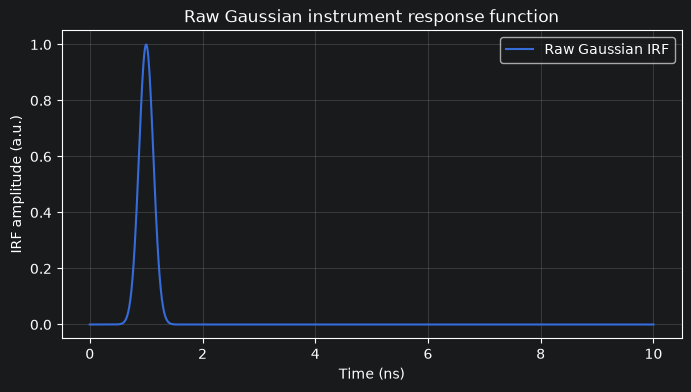

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    time,
    raw_irf,
    label="Raw Gaussian IRF",
)

ax.set(
    xlabel="Time (ns)",
    ylabel="IRF amplitude (a.u.)",
    title="Raw Gaussian instrument response function",
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

The centre controls the temporal location of the IRF peak, while the FWHM
controls its temporal width. At this stage, the area under the curve is not
necessarily equal to one.

## 6. Normalizing the IRF

For convolution, the IRF is treated as a temporal redistribution kernel.
Its continuous area is normalized to one:

$$
\int \mathrm{IRF}(t)\,dt = 1.
$$

After normalization, convolution redistributes the fluorescence signal in
time without introducing an arbitrary multiplicative factor determined by
the original IRF amplitude.

Normalization removes the absolute scale of the raw Gaussian. The normalized
shape still depends on the centre and FWHM.

In [10]:
normalized_irf = normalize_irf(
    time=time,
    irf=raw_irf,
)

raw_irf_area = np.trapezoid(
    raw_irf,
    x=time,
)

normalized_irf_area = np.trapezoid(
    normalized_irf,
    x=time,
)

print(f"Raw IRF area: {raw_irf_area:.6f}")
print(f"Normalized IRF area: {normalized_irf_area:.6f}")
print(f"Raw IRF maximum: {raw_irf.max():.6f}")
print(f"Normalized IRF maximum: {normalized_irf.max():.6f}")

Raw IRF area: 0.319340
Normalized IRF area: 1.000000
Raw IRF maximum: 1.000000
Normalized IRF maximum: 3.131458


In [11]:
assert normalized_irf.shape == time.shape
assert np.all(normalized_irf >= 0.0)
assert np.isclose(
    normalized_irf_area,
    1.0,
    rtol=1e-6,
    atol=1e-8,
)

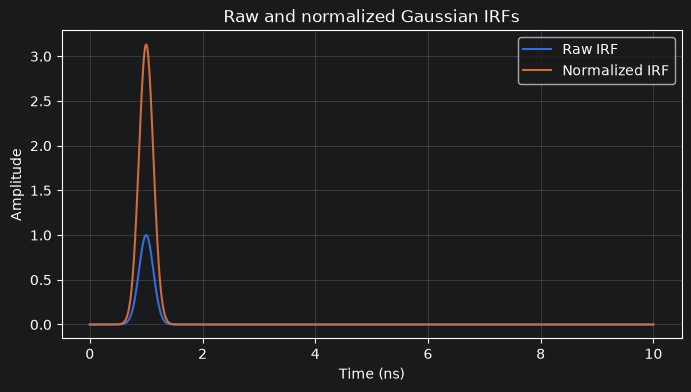

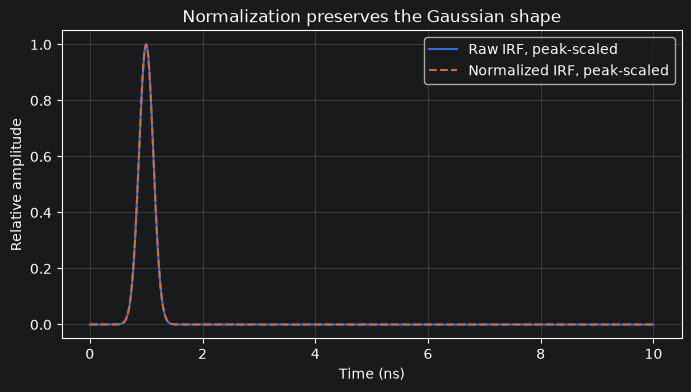

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    time,
    raw_irf,
    label="Raw IRF",
)

ax.plot(
    time,
    normalized_irf,
    label="Normalized IRF",
)

ax.set(
    xlabel="Time (ns)",
    ylabel="Amplitude",
    title="Raw and normalized Gaussian IRFs",
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()


raw_irf_rescaled = raw_irf / raw_irf.max()
normalized_irf_rescaled = normalized_irf / normalized_irf.max()

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    time,
    raw_irf_rescaled,
    label="Raw IRF, peak-scaled",
)

ax.plot(
    time,
    normalized_irf_rescaled,
    linestyle="--",
    label="Normalized IRF, peak-scaled",
)

ax.set(
    xlabel="Time (ns)",
    ylabel="Relative amplitude",
    title="Normalization preserves the Gaussian shape",
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

The first plot shows that normalization changes the numerical scale of the
IRF. The second plot divides both curves by their maxima and confirms that
normalization does not change the Gaussian centre or FWHM.

It changes the area and peak height, but not the relative shape.

### Effect of the raw Gaussian amplitude

Two Gaussian IRFs with the same centre and FWHM but different raw amplitudes
become identical after area normalization.

The raw amplitude is therefore useful for constructing an unnormalized
function, but it does not remain as an independent physical parameter once
the IRF is normalized to unit area.

In [15]:
raw_irf_low = generate_gaussian_irf(
    time=time,
    centre=irf_centre,
    fwhm=irf_fwhm,
    amplitude=1.0,
)

raw_irf_high = generate_gaussian_irf(
    time=time,
    centre=irf_centre,
    fwhm=irf_fwhm,
    amplitude=10.0,
)

normalized_irf_low = normalize_irf(
    time=time,
    irf=raw_irf_low,
)

normalized_irf_high = normalize_irf(
    time=time,
    irf=raw_irf_high,
)

maximum_difference = np.max(
    np.abs(normalized_irf_low - normalized_irf_high)
)

print(
    "Maximum difference between normalized IRFs: "
    f"{maximum_difference:.3e}"
)

np.testing.assert_allclose(
    normalized_irf_low,
    normalized_irf_high,
)

Maximum difference between normalized IRFs: 4.441e-16


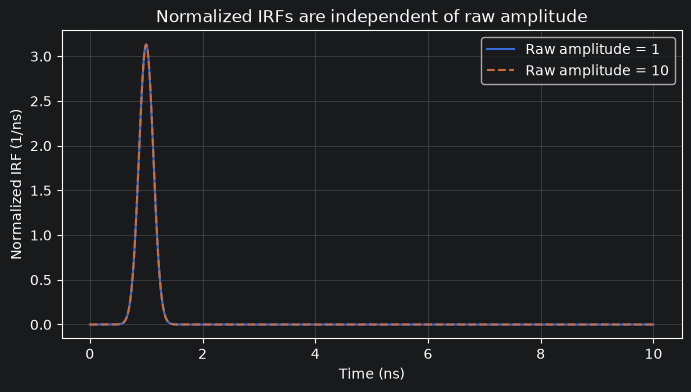

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    time,
    normalized_irf_low,
    label="Raw amplitude = 1",
)

ax.plot(
    time,
    normalized_irf_high,
    linestyle="--",
    label="Raw amplitude = 10",
)

ax.set(
    xlabel="Time (ns)",
    ylabel="Normalized IRF (1/ns)",
    title="Normalized IRFs are independent of raw amplitude",
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

## 7. Applying temporal shifts

The recorded IRF and fluorescence histogram may not have perfectly aligned
time origins. A temporal shift is therefore often needed.

The shift convention used by the toolkit is

$$
\mathrm{IRF}_{\Delta t}(t)
=
\mathrm{IRF}(t-\Delta t).
$$

Consequently:

- a positive shift moves the IRF toward later times;
- a negative shift moves the IRF toward earlier times.

Interpolation permits shifts that are not integer multiples of the time-bin
width. Values outside the observed time interval are filled with zero.

In [17]:
positive_shift = 0.5
negative_shift = -0.5

irf_shifted_later = shift_irf(
    time=time,
    irf=normalized_irf,
    shift=positive_shift,
)

irf_shifted_earlier = shift_irf(
    time=time,
    irf=normalized_irf,
    shift=negative_shift,
)

print(
    "Original peak time: "
    f"{time[np.argmax(normalized_irf)]:.3f} ns"
)
print(
    "Later-shifted peak time: "
    f"{time[np.argmax(irf_shifted_later)]:.3f} ns"
)
print(
    "Earlier-shifted peak time: "
    f"{time[np.argmax(irf_shifted_earlier)]:.3f} ns"
)

Original peak time: 1.000 ns
Later-shifted peak time: 1.500 ns
Earlier-shifted peak time: 0.500 ns


In [18]:
assert irf_shifted_later.shape == time.shape
assert irf_shifted_earlier.shape == time.shape

assert (
    time[np.argmax(irf_shifted_later)]
    >
    time[np.argmax(normalized_irf)]
)

assert (
    time[np.argmax(irf_shifted_earlier)]
    <
    time[np.argmax(normalized_irf)]
)

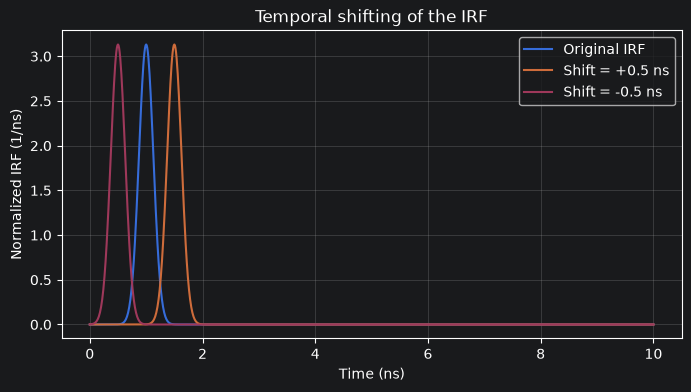

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    time,
    normalized_irf,
    label="Original IRF",
)

ax.plot(
    time,
    irf_shifted_later,
    label=f"Shift = +{positive_shift:.1f} ns",
)

ax.plot(
    time,
    irf_shifted_earlier,
    label=f"Shift = {negative_shift:.1f} ns",
)

ax.set(
    xlabel="Time (ns)",
    ylabel="Normalized IRF (1/ns)",
    title="Temporal shifting of the IRF",
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

The shifted curves retain the same general width. However, zero filling at
the time-window boundaries can remove part of an IRF if a sufficiently large
shift moves it outside the recorded interval.

For the main simulation, we will use the normalized unshifted IRF. The
boundary effect will be examined separately later.

In [20]:
irf = normalized_irf.copy()

assert irf.shape == time.shape

## 8. Generating an ideal fluorescence decay

We now generate the underlying fluorescence model without detector
background:

$$
I_{\mathrm{fl}}(t)
=
A\exp\left(-\frac{t}{\tau}\right).
$$

The background argument is explicitly set to zero because detector background
must not be included inside the signal that is convolved with the IRF.

In [21]:
ideal_fluorescence = monoexponential_decay(
    time=time,
    amplitude=amplitude,
    lifetime=lifetime,
    background=0.0,
)

print(f"ideal_fluorescence.shape: {ideal_fluorescence.shape}")
print(
    "Initial fluorescence value: "
    f"{ideal_fluorescence[0]:.3f}"
)
print(
    "Final fluorescence value: "
    f"{ideal_fluorescence[-1]:.6f}"
)

ideal_fluorescence.shape: (1001,)
Initial fluorescence value: 1000.000
Final fluorescence value: 0.045400


In [22]:
assert ideal_fluorescence.shape == time.shape
assert np.all(np.isfinite(ideal_fluorescence))
assert np.all(ideal_fluorescence >= 0.0)
assert np.isclose(
    ideal_fluorescence[0],
    amplitude,
)

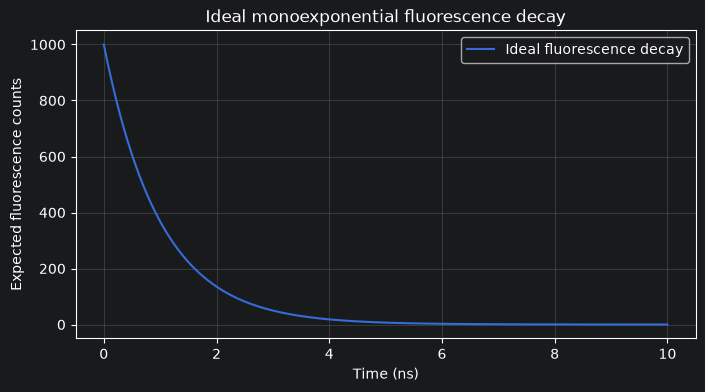

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    time,
    ideal_fluorescence,
    label="Ideal fluorescence decay",
)

ax.set(
    xlabel="Time (ns)",
    ylabel="Expected fluorescence counts",
    title="Ideal monoexponential fluorescence decay",
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

The ideal decay begins immediately at $t=0$. A real instrument response will
delay and broaden its leading edge. The convolution can therefore change both
the apparent peak position and the early-time shape.

## 9. Convolving the fluorescence decay with the IRF

The instrument-broadened fluorescence signal is calculated with

$$
I_{\mathrm{conv}}(t)
=
[\mathrm{IRF} * I_{\mathrm{fl}}](t).
$$

Both input arrays use the same time grid. The convolution implementation
returns an array aligned to the original time axis and with the same shape as
the input decay.

The time-bin width is accounted for by the convolution function so that an
area-normalized IRF behaves as a temporal redistribution kernel.

In [24]:
convolved_fluorescence = convolve_decay_with_irf(
    time=time,
    decay=ideal_fluorescence,
    irf=irf,
)

print(
    "convolved_fluorescence.shape: "
    f"{convolved_fluorescence.shape}"
)
print(
    "Maximum convolved fluorescence: "
    f"{convolved_fluorescence.max():.3f}"
)
print(
    "Time of convolved maximum: "
    f"{time[np.argmax(convolved_fluorescence)]:.3f} ns"
)

convolved_fluorescence.shape: (1001,)
Maximum convolved fluorescence: 768.725
Time of convolved maximum: 1.210 ns


In [25]:
assert convolved_fluorescence.shape == time.shape
assert np.all(np.isfinite(convolved_fluorescence))
assert np.all(convolved_fluorescence >= 0.0)


## 10. Comparing ideal and convolved fluorescence signals

The ideal and convolved curves are first compared on a linear scale. This view
emphasizes the leading edge and peak region, where IRF broadening is usually
most visible.

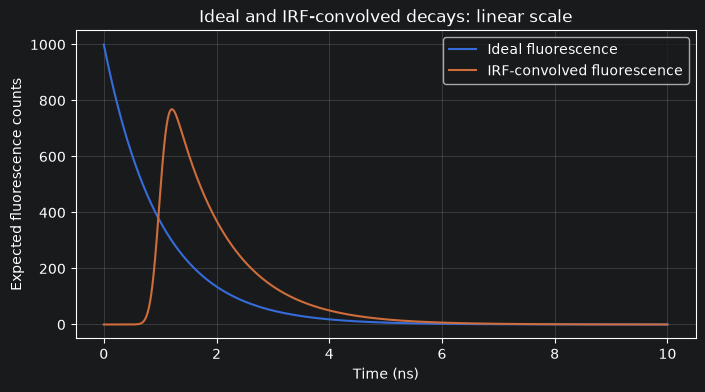

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    time,
    ideal_fluorescence,
    label="Ideal fluorescence",
)

ax.plot(
    time,
    convolved_fluorescence,
    label="IRF-convolved fluorescence",
)

ax.set(
    xlabel="Time (ns)",
    ylabel="Expected fluorescence counts",
    title="Ideal and IRF-convolved decays: linear scale",
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

The ideal model begins at its maximum at $t=0$, whereas the convolved signal
develops according to the finite temporal response of the instrument.

The convolved signal can have:

- a delayed maximum;
- a broadened leading edge;
- a reduced peak height;
- redistribution of signal into later time bins.

The exact appearance also depends on how the IRF is positioned relative to
the beginning of the time window.

A logarithmic vertical scale makes the decay tail easier to inspect. It is
especially useful for determining whether the long-time slope remains close
to the underlying monoexponential behaviour after the early-time IRF
distortion.

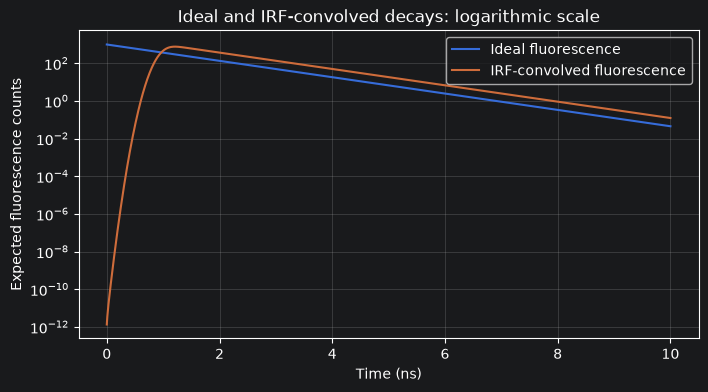

In [33]:
positive_ideal = np.maximum(
    ideal_fluorescence,
    np.finfo(float).tiny,
)

positive_convolved = np.maximum(
    convolved_fluorescence,
    np.finfo(float).tiny,
)

fig, ax = plt.subplots(figsize=(8, 4))

ax.semilogy(
    time,
    positive_ideal,
    label="Ideal fluorescence",
)

ax.semilogy(
    time,
    positive_convolved,
    label="IRF-convolved fluorescence",
)

ax.set(
    xlabel="Time (ns)",
    ylabel="Expected fluorescence counts",
    title="Ideal and IRF-convolved decays: logarithmic scale",
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

The early-time region differs strongly because it contains the IRF-induced
rise and broadening. At sufficiently late times, the convolved curve may
approach a decay slope similar to that of the underlying fluorescence model,
particularly when the lifetime is much longer than the IRF width.